# Elastic wave temporal convergence tutorial

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates how to investigate temporal and spatial
convergence for isotropic elastic wave propagation in Spiro.

We will:
1. Introduce the concept of convergence;
2. Things to check looking at convergence;
3. Measure temporal convergence by refining the time step;
4. Calculate the observed convergence rate.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import spyro

## 1. What is convergence?

A numerical solution should approach the exact solution as the discretization is refined according to the order of convergence.

For a numerical solution with error E and discretization parameter $\text{d}t$, we expect

$ \frac{|E(\text{d}t)|}{|\text{d}t|^p} \approx C $,

where p is the convergence order (don't confuse this with spatial polynomial order).

The same is true for our mesh discretization parameter of edge length $h$.

In Spiro we consider two types of discretization:

* Temporal discretization: the time step $\text{d}t$;
* Spatial discretization: the mesh edge length $h$.

However, for this tutorial we will focus on the temporal discretizaion.

Let us set up an homogeneos isotropic medium elastic wave propagation dictionary to be reused with different $\text{d}t$ values.

In [2]:
vp = 1.5
vs = 1.0
rho = 0.1

source_z = -2.0
receiver_z = -3.0
source_locations = [(source_z, -source_z)]
receiver_locations = [(receiver_z, -receiver_z)]
final_time = 1.5

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 6.0,
        "length_x": 6.0,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": source_locations,
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": 0.005,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}
dictionary["synthetic_data"] = {
    "type": "object",
    "density": rho,
    "p_wave_velocity": vp,
    "s_wave_velocity": vs,
    "real_velocity_file": None,
}
wave = spyro.IsotropicWave(dictionary)


Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters


/workspaces/qol_upgrades/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


# 2. Before looking at convergence

One common mistake when comparing with other softwares or analytical solutions is not noticing a time shift. This can occur simply because:
* Spiro's convention of initial or final time is shifted by dt to the reference solution;
* The source wavelet delay is different.

However, this wave-fornt time shift can also signify dispersion error or something else.

To analyze this, we will begin by adding a wrapper to Spiro's 2D analytical solution method, so we can vary only the timestep and get an analytical solution result measured at that timestep.

In [3]:
offsets = np.array(source_locations[0]) - np.array(receiver_locations[0])

def get_analytical_solution(dt):
    return spyro.utils.analytical_solution_elastic(
        source_type="force_source",
        offsets=offsets,
        p_wave_velocity=vp,
        s_wave_velocity=vs,
        density=rho,
        amplitude=1.0,
        frequency=5.0,
        time_delay=0.2,
        final_time=final_time,
        dt=dt,
        force_direction=1,
        dimension=2,
    )

Let us set a small element length h of 0.05 km to begin and get our first numerical result.

In [4]:
%%capture
wave.set_mesh(input_mesh_parameters={"edge_length": 0.1, "periodic": False})
wave.forward_solve()

We can compare our numerical solution to our analytical solution visualy by looking at the plot of displacement in each direction.

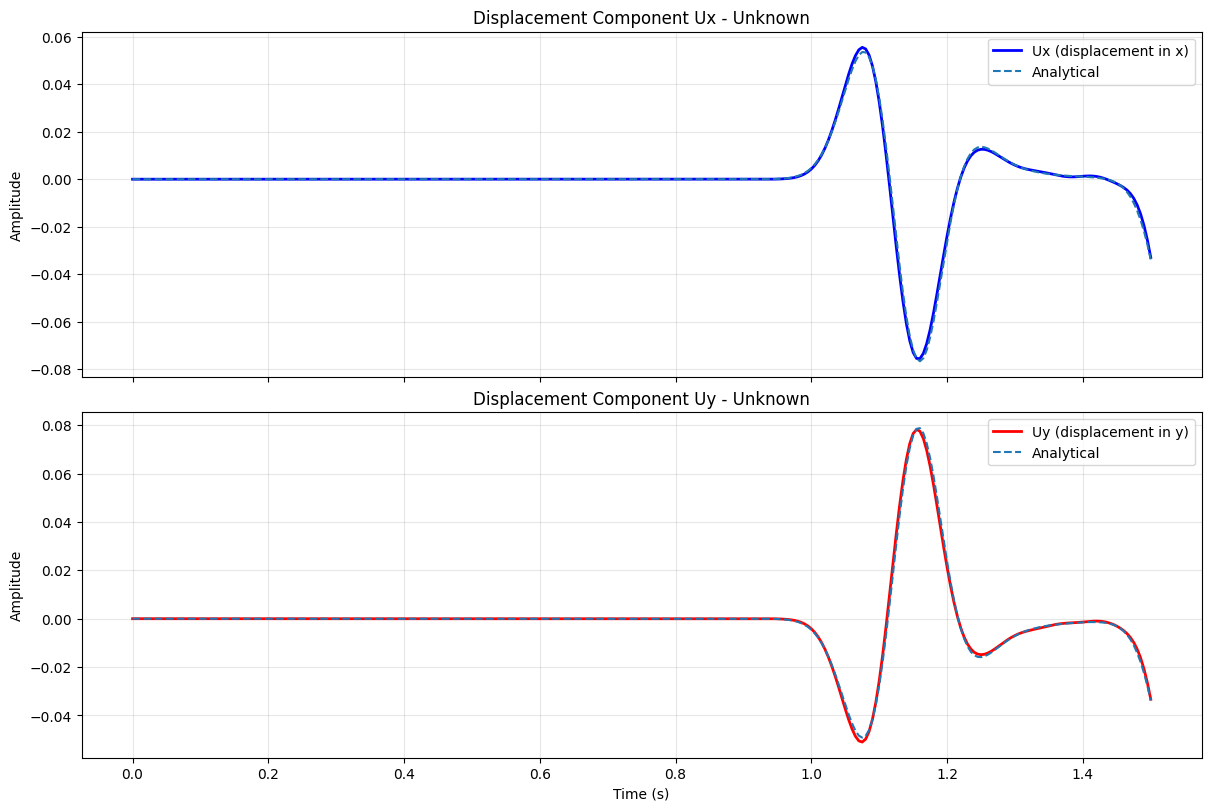

In [5]:
time_vector = spyro.utils.get_time_vector(wave)
fig = spyro.plots.plot_displacement_components(
    time_vector=time_vector,
    receiver_results=wave.forward_solution_receivers[:, 0 ,:],
    hold=True,
)
axes = fig.get_axes()
analytical_solution = get_analytical_solution(0.005)
axes[0].plot(time_vector, analytical_solution[0], "--", label="Analytical")
axes[0].legend()
axes[1].plot(time_vector, analytical_solution[1], "--", label="Analytical")
axes[1].legend()

By looking at the figure above, we can clearly see that even with element size of 0.1 km and timestep of 0.005 s we are very close to our anaylitical solution. I will shift my analytical solution one teime-step so we can look at how it would seem if it was shifted. 

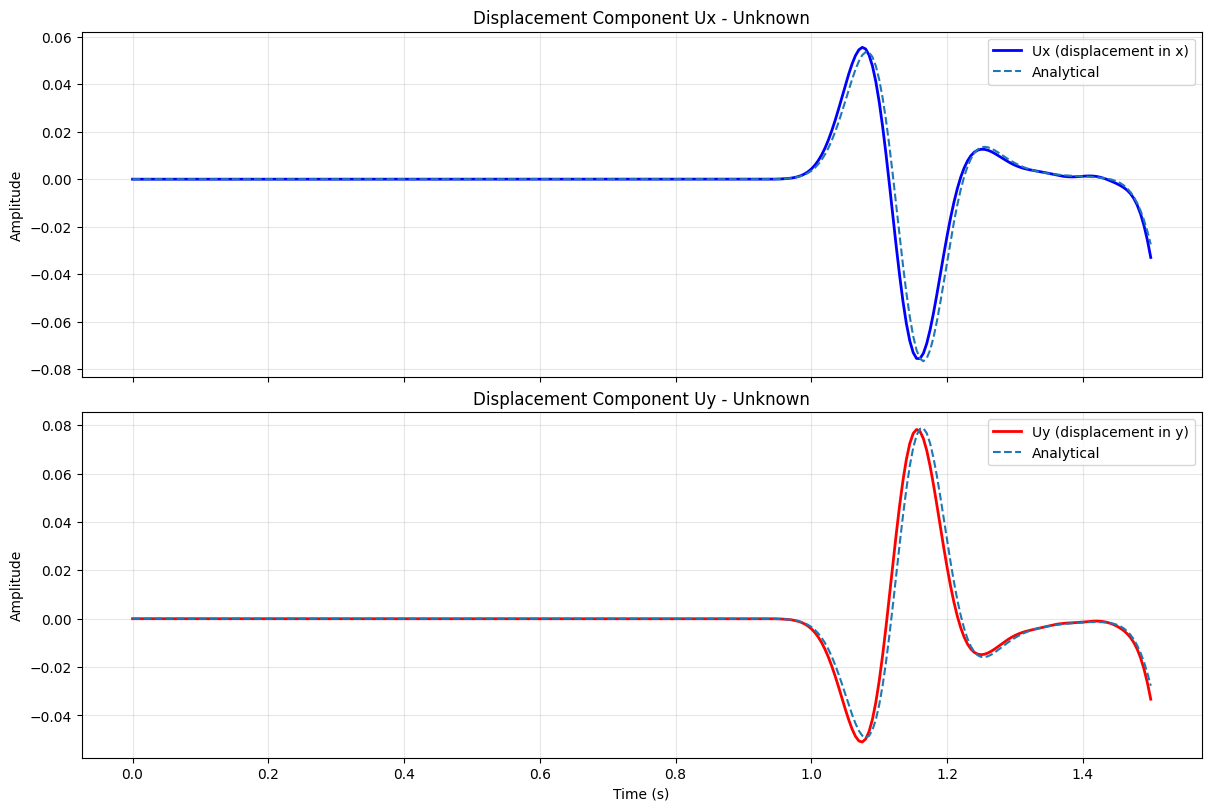

In [6]:
shifted_analytical_solution = [
    analytical_solution[0].copy(),
    analytical_solution[1].copy(),
]
shifted_analytical_solution[0][1:] = shifted_analytical_solution[0][:-1]
shifted_analytical_solution[1][1:] = shifted_analytical_solution[1][:-1]

time_vector = spyro.utils.get_time_vector(wave)
fig = spyro.plots.plot_displacement_components(
    time_vector=time_vector,
    receiver_results=wave.forward_solution_receivers[:, 0 ,:],
    hold=True,
)
axes = fig.get_axes()
analytical_solution = get_analytical_solution(0.005)
axes[0].plot(time_vector, shifted_analytical_solution[0], "--", label="Analytical")
axes[0].legend()
axes[1].plot(time_vector, shifted_analytical_solution[1], "--", label="Analytical")
axes[1].legend()

We can measure this shift. SInce I shifted one timestep I expect the measurement to have an absolute value equal to a timestep (0.005).

In [8]:
from scipy.signal import correlate

def estimate_time_shift(
    time_vector,
    numerical,
    reference,
):
    """Estimate the time shift between numerical and reference signals."""
    numerical = numerical - np.mean(numerical)
    reference = reference - np.mean(reference)

    correlation = correlate(
        numerical,
        reference,
        mode="full",
    )

    lag_samples = np.argmax(correlation) - (len(reference) - 1)

    dt = time_vector[1] - time_vector[0]

    return lag_samples * dt

time_shift = estimate_time_shift(time_vector, wave.forward_solution_receivers[:, 0 , 0], shifted_analytical_solution[0])

print(f"Time shift observed of {time_shift}.")

Time shift observed of -0.005.


## 4. Temporal convergence

To investigate temporal convergence, we keep the spatial discretization
fixed and progressively reduce the time step. The spatial discretization should be sufficiently fine so that the temporal error is the dominant source of numerical error.

We will use different timesteps and compare every numerical solution with the analytical solution. SInce we are using a central convergence timestepping scheme we should notive second order converge in time. 